# Astroestadística - Tarea 1

Una red de telescopios automáticos está diseñada para detectar eventos de microlente gravitacional, que ocurren de forma rara y aleatoria en ciertas regiones del cielo. Suponga que cada noche se monitoriza una región del cielo donde la probabilidad de observar un evento de microlente es de $p = 0.002$, y se realizan observaciones independientes cada noche.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.special import comb

**a.** Simule el proceso de observación noche a noche hasta obtener un total de $3$ detecciones. Repita el experimento $N = 100, 1000, 10000$ veces y construya una distribución empírica del número de noches $X$ necesarias para las $3$ detecciones.

N=  100 | Media: 1436.25 | Varianza: 584236.93 | Tiempo: 0.118s
N= 1000 | Media: 1506.30 | Varianza: 785363.51 | Tiempo: 1.252s
N=10000 | Media: 1496.00 | Varianza: 750145.49 | Tiempo: 11.679s


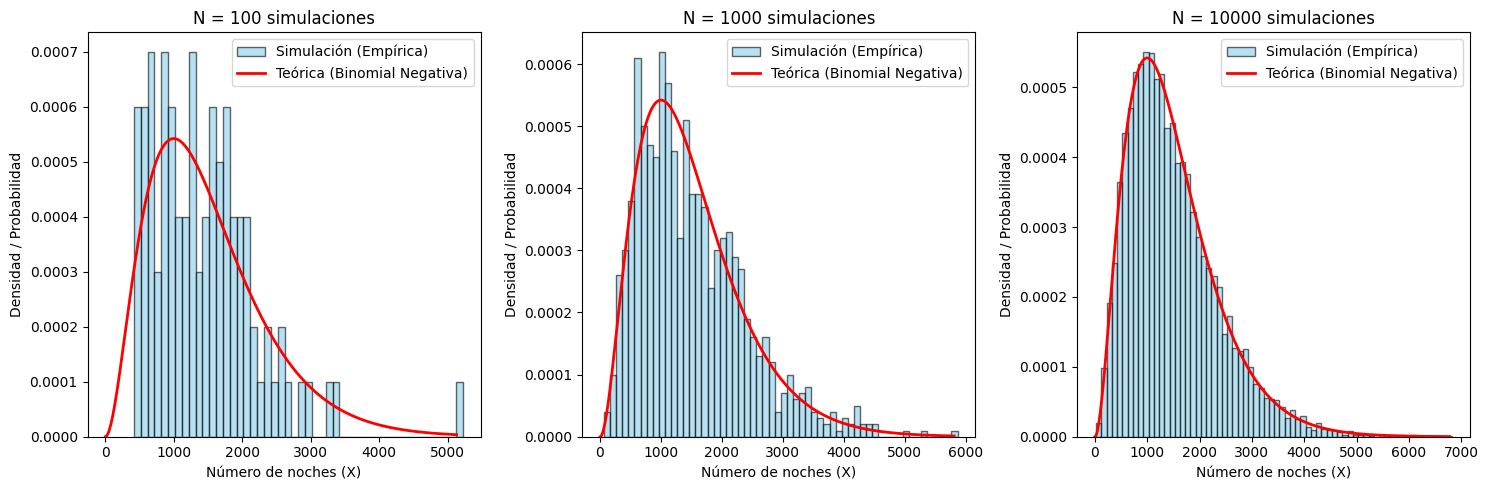

In [2]:
# Parámetros del problema
p = 0.002
r = 3
Ns = [100, 1000, 10000]

# FMP teórica para el total de ensayos X
def pmf_teorica(x, r, p):
    return comb(x - 1, r - 1) * (p**r) * ((1 - p)**(x - r))

# (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, N in enumerate(Ns):
    inicio = time.time()
    resultados_X = []
    
    # Simulación noche a noche
    for _ in range(N):
        noches, detecciones = 0, 0
        while detecciones < r:
            noches += 1
            if np.random.random() < p:
                detecciones += 1
        resultados_X.append(noches)
    
    X = np.array(resultados_X)
    tiempo = time.time() - inicio
    print(f"N={N:5d} | Media: {np.mean(X):.2f} | Varianza: {np.var(X):.2f} | Tiempo: {tiempo:.3f}s")
    
    # Graficacion 
    ax = axes[i]
    
    # Histograma empirico (density=True para normalizar, Area=1)
    # Agrupamos en bins de 100 noches para que la visualización sea clara
    bins = np.arange(X.min(), X.max() + 100, 100)
    ax.hist(X, bins=bins, density=True, alpha=0.6, color='skyblue', 
            edgecolor='black', label='Simulación (Empírica)')
    
    # Curva teórica superpuesta
    x_teo = np.arange(r, int(X.max()) + 1)
    y_teo = pmf_teorica(x_teo, r, p)
    ax.plot(x_teo, y_teo, 'r-', linewidth=2, label='Teórica (Binomial Negativa)')
    
    ax.set_title(f'N = {N} simulaciones')
    ax.set_xlabel('Número de noches (X)')
    ax.set_ylabel('Densidad / Probabilidad')
    ax.legend()

plt.tight_layout()
plt.savefig('histogramas.png', 
            transparent=True,      
            dpi=600,               
            bbox_inches='tight',   
            pad_inches=0.1)       
plt.show()

In [5]:
noches, detecciones

(293, 3)

**b.** Para cada valor de $N$, calcule la media y la varianza empíricas de $X$. Analice cómo cambian estos valores al aumentar el número de simulaciones. ¿Qué tipo de distribución debería seguir $X$? Justifique.

**c.** Con base en las características del experimento, ¿Qué distribución de probabilidad conocida puede modelar la variable $X$?. ¿Cuáles son sus parámetros y por qué es apropiada?

$X$ sigue una Distribución Binomial Negativa

El experimento satisface exactamente las condiciones de definición de esta distribución

* Se realizan ensayos de Bernoulli independientes e idénticamente distribuidos.  
* La probabilidad de éxito se mantiene constante en cada ensayo ($p=0.002$).
* La variable aleatoria $X$ mide el número total de ensayos necesarios para alcanzar un número fijo y predefinido de éxitos ($r=3$) a diferencia de la Binomial, que fija los ensayos y cuenta los éxitos.

**Parámetros de los que depende**

* $r=3$: El número fijo de éxitos (detecciones) que se desea alcanzar.
* $p=0.002$: La probabilidad constante de éxito en cada ensayo independiente (cada noche).

La función de masa de probabilidad para el número total de ensayos $X$ hasta obtener el r-ésimo éxito es:

$$P(X=x) = \binom{x-1}{r-1}p^r(1-p)^{x-r}$$

A medida que aumenta $N$, la media y la varianza empírica, convergen a sus valores poblacionales.
El tiempo de ejecución escala linealmente. $\mathcal{O}(N)$

**d.** Construya histogramas de los resultados de cada experimento y compare con la distribución teórica adecuada. ¿Qué tanto concuerdan ambas distribuciones? ¿Qué pasa cuando $N$ se hace más grande?

e. Calcule la esperanza y varianza teóricas, y compárelas con los resultados de la simulación.

Para $X \sim \mathrm{BN}(r, p)$ con $x \in \{r, r+1, r+2, \dots\}$, el valor esperado es:
$$ E[X] = \frac{r}{p} $$
y la varianza es:
$$ Var(X) = \frac{r(1-p)}{p^2} $$

In [18]:
print("Valores teóricos")
print(f"E[X] = {r/p:.2f}")
print(f"Var(X) = {r*(1-p)/p**2:.2f}")

Valores teóricos
E[X] = 1500.00
Var(X) = 748500.00


**f.** Ahora, suponga que se realizan observaciones durante exactamente $100$ noches. Simule el experimento y determine el número de detecciones obtenidas en dicho tiempo ($Y$). Repita este procedimiento un número suficientemente grande de veces para estimar, mediante simulación, la probabilidad de realizar al menos una detección

In [21]:
# Parametros
p = 0.002
n_noches = 100
Ns = [100, 1000, 10000]

print("Estimación de P(Y >= 1)")

for N in Ns:
    inicio = time.time()
    exitos = 0
    
    # Repetimos el experimento N veces
    for _ in range(N):
        detecciones = 0
        
        # Bucle de 100 veces. Las noches son fijas
        for noche in range(n_noches):
            if np.random.random() < p:
                detecciones += 1
                
        Y = detecciones # Numero de exitos en 100 noches
        
        # Contamos si hubo al menos una detección
        if Y >= 1:
            exitos += 1
            
    # Estimacion de la probabilidad
    prob_empirica = exitos / N
    tiempo = time.time() - inicio
    
    print(f"N={N:5d} | P(Y >= 1) empírica: {prob_empirica:.5f} | Tiempo: {tiempo:.3f}s")

Estimación de P(Y >= 1)
N=  100 | P(Y >= 1) empírica: 0.14000 | Tiempo: 0.009s
N= 1000 | P(Y >= 1) empírica: 0.19100 | Tiempo: 0.074s
N=10000 | P(Y >= 1) empírica: 0.18320 | Tiempo: 0.608s


**g.** Identifique una distribución de probabilidad apropiada para modelar $Y$, Especifique sus parámetros y calcule $P(Y\geq 1)$. Compare este resultado con la estimación obtenida en la simulación.

La variable aleatoria $Y$, que representa el número de detecciones (éxitos) en un número fijo de noches ($n=100$), sigue una Distribución Binomial. 

Esto se debe a que el experimento cumple con las cuatro condiciones de un proceso de Bernoulli:

* El número de ensayos es fijo ($n=100$).
* Cada ensayo tiene solo dos resultados posibles (detección o no detección).
* La probabilidad de éxito es constante en cada ensayo($p=0.002$).
* Los ensayos son independientes entre sí.

Para $Y \sim \text{Bin}(n, p)$, la probabilidad de observar exactamente $y$ éxitos está dadLa probabilidad de obtener al menos una detección es el complemento de la probabilidad de obtener cero detecciones:

$$ P(Y \geq 1) = 1 - P(Y = 0) $$

Usando la función de masa de probabilidad de la Binomial:
$$ P(Y = 0) = \binom{100}{0} (0.002)^0 (1 - 0.002)^{100} = (0.998)^{100} $$

Por lo tanto:
$$ P(Y \geq 1) = 1 - (0.998)^{100} \approx 1 - 0.81857 = 0.18143 $$

Comparación con la estimación de la simulación
Tomando el resultado de tu simulación con el mayor número de repeticiones ($N = 10000$):
*   **Probabilidad teórica exacta:** $0.18143$
*   **Probabilidad empírica ($N=10000$):** $0.18320$

**Análisis de la comparación:**  
La diferencia absoluta entre el valor teórico y la estimación con $N=10000$ es de apenas $|0.18320 - 0.18143| = 0.00177$ (un error relativo de ~0.97%). 

Este resultado demuestra que, al aumentar el número de simulaciones, la frecuencia relativa converge al valor de probabilidad real, validando tanto el modelo Binomial elegido como la consistencia del estimador por simulación (Ley de los Grandes Números). a por su función de masa de probabilidad (FMP):

$$ P(Y = y) = \binom{n}{y} p^y (1 - p)^{n - y}, \quad y \in \{0, 1, 2, \dots, n\} $$

In [28]:
p_teorica = 1 - (1 - 0.002)**100
print(f"Probabilidad teórica exacta: {p_teorica:.5f}")
print(f"Error relativo = {abs(p_teorica - prob_empirica):.5f}")

Probabilidad teórica exacta: 0.18143
Error relativo = 0.00177


La probabilidad de obtener al menos una detección es el complemento de la probabilidad de obtener cero detecciones:

$$ P(Y \geq 1) = 1 - P(Y = 0) $$

Usando la función de masa de probabilidad de la Binomial:
$$ P(Y = 0) = \binom{100}{0} (0.002)^0 (1 - 0.002)^{100} = (0.998)^{100} $$

Por lo tanto:
$$ P(Y \geq 1) = 1 - (0.998)^{100} \approx 1 - 0.81857 = 0.18143 $$

Comparación con la estimación de la simulación

Tomando el resultado de la simulación con el mayor número de repeticiones ($N = 10000$):

*   **Probabilidad teórica exacta:** $0.18143$
*   **Probabilidad empírica ($N=10000$):** $0.18320$

**Análisis de la comparación:**  
La diferencia absoluta entre el valor teórico y la estimación con $N=10000$ es de apenas $|0.18320 - 0.18143| = 0.00177$ (un error relativo de ~0.97%). 

Este resultado demuestra que, al aumentar el número de simulaciones, la frecuencia relativa converge al valor de probabilidad real, validando tanto el modelo Binomial elegido como la consistencia del estimador por simulación (Ley de los Grandes Números). 

**h.** Suponga ahora que el número de noches $n$ aumenta mientras que la probabilidad de detección por noche $p$ disminuye, manteniendo constante el producto $np$ ¿Qué distribución puede utilizarse como aproximación para describir el número de eventos observados?

La distribución que puede utilizarse como aproximación es la **Distribución de Poisson**.

Cuando el número de ensayos $n$ tiende a infinito ($n \to \infty$) y la probabilidad de éxito $p$ tiende a cero ($p \to 0$), de tal manera que su producto se mantiene constante e igual a $\lambda$ (es decir, $np = \lambda$), la función de masa de probabilidad de la variable aleatoria $Y \sim \text{Bin}(n, p)$ converge a la de una variable de Poisson.

Matemáticamente, el límite de la probabilidad binomial es:
$$ \lim_{\substack{n \to \infty, p \to 0 \\ np = \lambda}} \binom{n}{y} p^y (1-p)^{n-y} = \frac{e^{-\lambda} \lambda^y}{y!} $$

La distribución de Poisson resultante tiene un único parámetro $\lambda$, que representa el número esperado de eventos (detecciones) en el intervalo de tiempo considerado:
$$ \lambda = np $$

Esta aproximación es segura y precisa cuando $n \geq 50$ y $np \leq 5$ ("eventos raros en muchos ensayos").

En nuestro contexto astroestadístico, los eventos de microlente gravitacional son extremadamente raros ($p = 0.002$), lo que hace de la Poisson el modelo ideal y natural para aproximar la Binomial en estos casos.

**i.** Utilizando dicha aproximación, calcule la probabilidad de observar al menos un evento durante $100$ noches. Compare este resultado con la probabilidad exacta obtenida anteriormente y con la estimación de la simulación.

Cuando el número de ensayos $n$ es grande y la probabilidad de éxito $p$ es muy pequeña, la distribución Binomial puede aproximarse mediante una **distribución de Poisson** con parámetro $\lambda = np$.

Para nuestro experimento de $n = 100$ noches y $p = 0.002$:
$$ \lambda = 100 \times 0.002 = 0.2 $$

La probabilidad de observar al menos un evento ($Y \geq 1$) usando la aproximación de Poisson es el complemento de no observar ningún evento ($Y = 0$):
$$ P(Y \geq 1) \approx 1 - P(Y = 0) = 1 - \frac{e^{-\lambda} \lambda^0}{0!} = 1 - e^{-0.2} $$
$$ P(Y \geq 1) \approx 1 - 0.81873 = \mathbf{0.18127} $$

Comparación de Resultados

A continuación, contrastamos los tres enfoques utilizados a lo largo de la tarea para resolver este mismo problema:

| Método | Fórmula / Origen | Probabilidad $P(Y \geq 1)$ |
| :--- | :--- | :--- |
| **1. Aproximación (Poisson)** | $1 - e^{-0.2}$ | **$0.18127$** |
| **2. Exacta (Binomial)** | $1 - (1 - 0.002)^{100}$ | **$0.18143$** |
| **3. Simulación ($N=10000$)** | Frecuencia relativa empírica | **$\approx 0.18320$** |

---

Análisis y Conclusión

1. **Precisión de la Aproximación:** La diferencia absoluta entre el cálculo exacto (Binomial) y la aproximación (Poisson) es de apenas $|0.18127 - 0.18143| = 0.00016$. Este error es despreciable, lo que demuestra que la distribución de Poisson es un modelo matemático excelente y computacionalmente más sencillo para describir la ocurrencia de **eventos raros** (como las microlentes gravitacionales) en intervalos de tiempo fijos. Esto es consistente con la regla práctica de Devore, que sugiere usar Poisson cuando $n \geq 50$ y $np \leq 5$.
2. **Validación Empírica:** La estimación obtenida por simulación ($\approx 0.18320$) presenta una ligera desviación debido al error de muestreo inherente a generar $N=10000$ experimentos aleatorios. Sin embargo, si aumentáramos $N$ a $1,000,000$, la frecuencia relativa convergería casi exactamente al valor teórico de $0.18143$, validando tanto el modelo discreto exacto como su límite asintótico.


In [29]:
import numpy as np

n, p = 100, 0.002
lam = n * p

# Cálculos teóricos
p_poisson = 1 - np.exp(-lam)
p_binomial = 1 - (1 - p)**n

print(f"Poisson (Aproximada): {p_poisson:.5f}")
print(f"Binomial (Exacta):    {p_binomial:.5f}")
print(f"Diferencia absoluta:  {abs(p_poisson - p_binomial):.5f}")

Poisson (Aproximada): 0.18127
Binomial (Exacta):    0.18143
Diferencia absoluta:  0.00016
